# RF Fingerprinting Notebook

Notebook-first workflow for real vs complex RF encoders with synthetic fallback data.

Modes:
- `fast`: quick smoke tests (small data, short training).
- `base`: balanced default for iteration.
- `full`: longer run for stronger comparison numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_auc_score

from config import load_config, save_scorecard_csv
from data import load_or_generate_npz
from datasets import AugmentedIQDataset, IQDataset, TwoViewIQDataset, TwoViewLabeledIQDataset, augment_iq, split_indices
from models import ComplexEncoder1D, RealEncoder1D, model_report
from training import (
    collect_logits,
    evaluate_identification,
    evaluate_open_set,
    evaluate_oscr,
    evaluate_verification,
    max_softmax_scores,
    open_set_scores,
    prototype_scores,
    mahalanobis_scores,
    knn_scores,
    compare_open_set_scores,
    calibrate_rejection_threshold,
    rejection_sweep,
    evaluate_rejection,
    evaluate_prototype_oscr,
    extract_embeddings,
    extract_embeddings_tta,
    finetune_classifier,
    outlier_exposure_finetune,
    pretrain_simclr,
    run_linear_probe,
    seed_everything,
    select_device,
)
from visualize import plot_history, plot_iq_views

device = select_device()

MODE = 'full'  # compute preset: 'fast', 'base', or 'full'
IMPAIRMENT_PROFILE = 'controlled'  # oracle, device_full, controlled, receiver_only, stress_channel, stress_waveform, default, full
IMPAIRMENT_ABLATION = None  # e.g. 'no_cfo', 'no_dc', 'no_channel', 'no_awgn'
EVALUATE_ENCODERS = ('real', 'complex')
COMPLEX_POOLING = 'stats'  # 'stats' preserves phase-aware statistics; 'avg' is magnitude-only
REAL_POOLING = 'stats'     # 'stats' enriches real encoder with mean+std+max; 'avg' is default
SUPCON_WEIGHT = 1.0        # supervised contrastive weight during pretraining (0 = pure SimCLR)
SUPCON_LAMBDA = 0.1        # supervised contrastive weight during fine-tuning (0 = pure CE)
KNOWN_DEVICE_COUNT = 5
UNKNOWN_DEVICE_COUNT = 5
UNKNOWN_CALIBRATION_DEVICE_COUNT = 2
MIN_UNKNOWN_SEPARATION = 2.0  # min impairment-std distance from each unknown device to every known device (0 = off)
TTA_VIEWS = 8                # augmented views averaged for embedding-based open-set scores (1 = single view)
KNN_K = 10               # neighbors for the kNN cosine open-set score
OE_WEIGHT = 1.0              # outlier-exposure weight for the logit-based open-set head (0 = off)
OE_EPOCHS = 3                # outlier-exposure head fine-tune epochs
OE_ENCODER_LR_SCALE = 0.1  # >0 also adapts the encoder during outlier exposure
RUN_CONTROL_PROFILES = ('oracle', 'device_full')  # negative/positive control profiles; () to skip

# Set an override to None to keep the value from MODE.
CONFIG_OVERRIDES = {
    'dataset_path': None,
    'output_dir': None,
    'seed': None,
    'seq_len': None,
    'n_devices': None,
    'n_sessions': None,
    'n_samples': None,
    'test_size': None,
    'val_size': None,
    'batch_size': None,
    'embed_dim': 128,
    'pretrain_epochs': 20,
    'finetune_epochs': 20,
    'lr': None,
    'weight_decay': None,
    'temperature': None,
    'noise_std': None,
    'phase_jitter_rad': None,
    'time_shift': None,
    'cfo_jitter_rad': None,
    'amplitude_jitter': None,
    'aug_prob': None,
    'grad_clip': None,
    'dropout': None,
    'encoder_lr_scale': None,
    'warmup_epochs': None,
    'n_receivers': None,
    'num_workers': None,
    'n_channels': None,
    'normalize_output': True,
    'quantization_scale': None,
    'quantization_bits': None,
}

cfg = load_config(mode=MODE, impairment_profile=IMPAIRMENT_PROFILE, impairment_ablation=IMPAIRMENT_ABLATION)
for field, value in CONFIG_OVERRIDES.items():
    if value is not None:
        setattr(cfg, field, value)
if KNOWN_DEVICE_COUNT < 2 or UNKNOWN_DEVICE_COUNT < 1:
    raise ValueError('Need at least two known devices and one unknown device.')
if not 0 <= UNKNOWN_CALIBRATION_DEVICE_COUNT < UNKNOWN_DEVICE_COUNT:
    raise ValueError('UNKNOWN_CALIBRATION_DEVICE_COUNT must be less than UNKNOWN_DEVICE_COUNT.')
cfg.n_devices = KNOWN_DEVICE_COUNT + UNKNOWN_DEVICE_COUNT
cfg.known_device_count = KNOWN_DEVICE_COUNT
cfg.unknown_min_separation = MIN_UNKNOWN_SEPARATION
if cfg.pretrain_epochs < 1 or cfg.finetune_epochs < 1:
    raise ValueError('pretrain_epochs and finetune_epochs must each be at least 1.')
cfg.validate_impairments()

print({
    'mode': cfg.mode,
    'n_samples': cfg.n_samples,
    'batch_size': cfg.batch_size,
    'pretrain_epochs': cfg.pretrain_epochs,
    'finetune_epochs': cfg.finetune_epochs,
    'output_dir': cfg.output_dir,
    'impairment_profile': cfg.impairment_profile,
    'impairment_ablation': cfg.impairment_ablation,
    'known_devices': KNOWN_DEVICE_COUNT,
    'unknown_devices': UNKNOWN_DEVICE_COUNT,
    'unknown_calibration_devices': UNKNOWN_CALIBRATION_DEVICE_COUNT,
    'min_unknown_separation': cfg.unknown_min_separation,
    'normalize_output': cfg.normalize_output,
})
print('device impairments:', cfg.device_impairments)
print('nuisance impairments:', cfg.nuisance_impairments)
cfg


{'mode': 'full', 'n_samples': 4000, 'batch_size': 128, 'pretrain_epochs': 20, 'finetune_epochs': 20, 'output_dir': '/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_full', 'impairment_profile': 'controlled', 'impairment_ablation': None, 'known_devices': 5, 'unknown_devices': 5, 'unknown_calibration_devices': 2, 'min_unknown_separation': 2.0, 'normalize_output': True}
device impairments: DeviceImpairments(iq_imbalance=True, cfo=True, phase_noise=True, pa_nonlinearity=True, pa_memory=True, dc_offset=False, iq_gain_std=0.03, iq_skew_std_rad=0.03, cfo_range_rad=(-0.003, 0.003), phase_noise_range=(0.0003, 0.0012), pa_range=(0.02, 0.08), memory_range=(-0.04, 0.04), dc_std=0.025)
nuisance impairments: NuisanceImpairments(session_channel=False, channel=False, receiver=True, waveform_variation=False, awgn=True, quantization=True, session_tap_scale=0.1, channel_tap_scale=0.12, snr_db_range=(16.0, 27.0))


RFConfig(mode='full', dataset_path='', output_dir='/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_full', seed=7, seq_len=256, n_devices=10, n_sessions=4, n_samples=4000, test_size=0.2, val_size=0.2, batch_size=128, embed_dim=128, pretrain_epochs=20, finetune_epochs=20, lr=0.001, weight_decay=0.0001, temperature=0.2, noise_std=0.03, phase_jitter_rad=0.03, time_shift=8, cfo_jitter_rad=0.0, amplitude_jitter=0.03, aug_prob=0.9, grad_clip=0.5, dropout=0.1, encoder_lr_scale=0.5, warmup_epochs=1, n_receivers=2, num_workers=0, n_channels=3, normalize_output=True, quantization_scale=2.0, quantization_bits=10, impairment_profile='controlled', impairment_ablation=None, device_impairments=DeviceImpairments(iq_imbalance=True, cfo=True, phase_noise=True, pa_nonlinearity=True, pa_memory=True, dc_offset=False, iq_gain_std=0.03, iq_skew_std_rad=0.03, cfo_range_rad=(-0.003, 0.003), phase_noise_range=(0.0003, 0.0012), pa_range=(0.02, 

## Experiment controls

The notebook separates compute settings from signal-generation settings. Change `MODE` for runtime cost, `IMPAIRMENT_PROFILE` for the synthetic RF conditions, `IMPAIRMENT_ABLATION` to disable one effect, and `COMPLEX_POOLING` to choose how the complex encoder summarizes its final activations.

`KNOWN_DEVICE_COUNT` controls enrolled devices and `UNKNOWN_DEVICE_COUNT` controls devices reserved entirely for open-set evaluation. The default is five known and five unknown devices. Unknown devices are not used for training or validation.

### Runtime modes

- `fast`: small dataset and short training; use for smoke tests and impairment iteration.
- `base`: moderate dataset and training budget; use for routine experiments.
- `full`: largest dataset and longest training budget; use for final comparisons.

Runtime modes do not change which impairments are enabled.

### Impairment profiles

- `oracle`: negative control. All device and capture impairments are disabled, so device identification should be near chance.
- `device_full`: all persistent device impairments are enabled, with no channel, receiver, waveform, noise, or quantization nuisance. Establishes the device-only upper bound.
- `controlled`: recommended learnable baseline. Uses reduced device impairment strengths with receiver effects, AWGN, and quantization, but disables session multipath, the second channel stage, and waveform variation.
- `receiver_only`: controlled device impairments plus receiver effects, AWGN, and quantization. Measures receiver robustness without multipath or modulation changes.
- `stress_channel`: controlled device impairments plus session multipath. Use to measure the impact of held-out channel conditions.
- `stress_waveform`: controlled device impairments plus waveform variation. Use to test whether device features generalize across BPSK, QPSK, and 16-QAM.
- `default`: preserves the original generator behavior, including stronger device ranges and DC offset. Use mainly for backward comparisons.
- `full`: enables the complete impairment stack. Treat this as a stress test, not the first baseline.

Recommended progression: `oracle` -> `device_full` -> `controlled` -> `receiver_only` -> `stress_channel`/`stress_waveform` -> `full`.

### Ablations

Set `IMPAIRMENT_ABLATION` to one of these values. An ablation disables only the named effect within the selected profile. Use `None` for no ablation.

- `no_iq`: disable transmitter I/Q gain and skew imbalance.
- `no_cfo`: disable persistent device carrier-frequency offset.
- `no_phase_noise`: disable device oscillator phase noise.
- `no_pa`: disable transmitter power-amplifier nonlinearity.
- `no_memory`: disable the transmitter memory term.
- `no_dc`: disable transmitter DC offset.
- `no_session_channel`: disable session-specific multipath.
- `no_channel`: disable the second channel multipath stage.
- `no_receiver`: disable receiver gain, phase, AGC, and receiver DC effects.
- `no_waveform_variation`: use the fixed reference waveform instead of randomly selecting modulation.
- `no_awgn`: disable receiver thermal noise.
- `no_quantization`: bypass receiver quantization.

For shortcut diagnosis, compare `controlled` against `controlled` + `no_cfo`, `no_dc`, and `no_iq`. For nuisance diagnosis, compare `device_full` with `stress_channel` and `stress_waveform`.

### Complex pooling

- `stats`: recommended. Retains magnitude statistics, real/imaginary statistics, and circular phase moments.
- `avg`: magnitude-only global average pooling. This is useful for a strict magnitude-based ablation, but discards activation phase.
- `max`: magnitude-only global max pooling. This emphasizes peak activations and is useful as a sensitivity test.

`stats` and `avg` are not equivalent comparisons: `avg` deliberately removes phase information that may carry RF fingerprint features.

### Open-set controls

- `MIN_UNKNOWN_SEPARATION`: minimum distance (in impairment-standard-deviation units) enforced between every unknown device and every known device during data generation. Guarantees unknown devices are distinguishable in principle; `0` disables the constraint for backward compatibility.
- `TTA_VIEWS`: number of augmented views averaged (after L2 normalization) when computing prototype-cosine and Mahalanobis open-set scores. Test-time augmentation smooths the noise realization and typically buys a few AUROC points at low SNR.
- `OE_WEIGHT` / `OE_EPOCHS`: outlier exposure. After fine-tuning, the classifier head is briefly re-trained so calibration-unknown samples are pushed toward uniform softmax while known samples keep their cross-entropy objective. The `oe_open_set_*_auroc` columns come from this head; they repair the below-chance logit-based scores that closed-set training produces.
- `RUN_CONTROL_PROFILES`: profiles run end-to-end after the main experiment and appended to the scorecard with their own `profile` label. The default runs `oracle` (negative control; open-set AUROC should stay near 0.5) and `device_full` (device-only upper bound). Set to `()` to skip.


In [2]:
data = load_or_generate_npz(cfg)
seed_everything(cfg.seed, deterministic=True)
print({k: v.shape for k, v in data.items() if hasattr(v, 'shape')})
metadata_unavailable = set(np.asarray(data.get('metadata_unavailable', []), dtype=str).tolist())
print('metadata_unavailable:', sorted(metadata_unavailable))
print('num_devices:', np.unique(data['device_id']).size)
if np.unique(data['device_id']).size != KNOWN_DEVICE_COUNT + UNKNOWN_DEVICE_COUNT:
    raise ValueError('Generated device count does not match KNOWN_DEVICE_COUNT + UNKNOWN_DEVICE_COUNT.')
print('waveform_counts:', np.bincount(data['waveform_id']))
print('snr_db_range:', (float(np.min(data['snr_db'])), float(np.max(data['snr_db']))))
if 'session_id' not in metadata_unavailable:
    print('num_sessions:', np.unique(data['session_id']).size)
if 'dist_to_nearest_known' in data:
    per_dev_dist = [float(np.mean(data['dist_to_nearest_known'][data['device_id'] == d])) for d in np.unique(data['device_id'])]
    print('dist_to_nearest_known per device:', [round(v, 2) for v in per_dev_dist])


{'iq': (4000, 256), 'device_id': (4000,), 'session_id': (4000,), 'receiver_id': (4000,), 'channel_id': (4000,), 'waveform_id': (4000,), 'snr_db': (4000,), 'dist_to_nearest_known': (4000,)}
metadata_unavailable: []
num_devices: 10
waveform_counts: [4000]
snr_db_range: (14.565768241882324, 29.124361038208008)
num_sessions: 4
dist_to_nearest_known per device: [2.29, 2.31, 2.29, 2.36, 2.31, 2.69, 2.72, 3.35, 2.23, 2.14]


In [3]:
all_devices = np.sort(np.unique(data['device_id']))
expected_device_count = KNOWN_DEVICE_COUNT + UNKNOWN_DEVICE_COUNT
if all_devices.size != expected_device_count:
    raise ValueError(f'Expected {expected_device_count} generated devices, found {all_devices.size}.')
known_devices = all_devices[:KNOWN_DEVICE_COUNT]
unknown_devices = all_devices[KNOWN_DEVICE_COUNT:]
unknown_calibration_devices = unknown_devices[:UNKNOWN_CALIBRATION_DEVICE_COUNT]
unknown_test_devices = unknown_devices[UNKNOWN_CALIBRATION_DEVICE_COUNT:]

def prepare_experiment(data, metadata_unavailable):
    """Build session-held-out splits and datasets for the current data/cfg globals."""
    global known_indices, unknown_indices, unknown_calibration_indices
    global known_labels, known_splits, split_strategy
    global train_indices, val_indices, test_indices
    global train_ds, val_ds, test_ds, unknown_ds, unknown_calibration_ds
    global two_view_ds, finetune_train_ds, num_classes
    known_mask = np.isin(data['device_id'], known_devices)
    unknown_mask = np.isin(data['device_id'], unknown_test_devices)
    unknown_calibration_mask = np.isin(data['device_id'], unknown_calibration_devices)
    known_indices = np.flatnonzero(known_mask)
    unknown_indices = np.flatnonzero(unknown_mask)
    unknown_calibration_indices = np.flatnonzero(unknown_calibration_mask)
    label_map = {int(label): i for i, label in enumerate(known_devices)}
    known_labels = np.asarray([label_map[int(label)] for label in data['device_id'][known_indices]], dtype=np.int64)
    # Prefer a true session-held-out split; otherwise combine every available nuisance field.
    if 'session_id' not in metadata_unavailable:
        known_splits = split_indices(len(known_indices), cfg.test_size, cfg.val_size, cfg.seed, session_ids=data['session_id'][known_indices], group_by='session')
        split_strategy = 'session-held-out'
    else:
        nuisance_names = [name for name in ('receiver_id', 'channel_id', 'waveform_id') if name in data and name not in metadata_unavailable]
        if not nuisance_names:
            raise ValueError(f'No session or nuisance metadata available; unavailable={sorted(metadata_unavailable)}')
        # split_indices accepts one-dimensional keys; encode the tuple without collisions.
        group_ids = np.asarray(['|'.join(map(str, values)) for values in zip(*(data[name][known_indices].tolist() for name in nuisance_names))], dtype=str)
        known_splits = split_indices(len(known_indices), cfg.test_size, cfg.val_size, cfg.seed, group_ids=group_ids)
        split_strategy = 'combined-nuisance-held-out'
    print('split_strategy:', split_strategy, 'known_devices:', known_devices.tolist(), 'unknown_calibration_devices:', unknown_calibration_devices.tolist(), 'unknown_test_devices:', unknown_test_devices.tolist())
    train_indices = known_indices[known_splits['train']]
    val_indices = known_indices[known_splits['val']]
    test_indices = known_indices[known_splits['test']]
    train_ds = IQDataset(data['iq'][train_indices], known_labels[known_splits['train']])
    val_ds = IQDataset(data['iq'][val_indices], known_labels[known_splits['val']])
    test_ds = IQDataset(data['iq'][test_indices], known_labels[known_splits['test']])
    unknown_ds = IQDataset(data['iq'][unknown_indices], np.zeros(len(unknown_indices), dtype=np.int64))
    unknown_calibration_ds = IQDataset(data['iq'][unknown_calibration_indices], np.zeros(len(unknown_calibration_indices), dtype=np.int64))
    two_view_ds = TwoViewLabeledIQDataset(data['iq'][train_indices], known_labels[known_splits['train']], cfg, seed=cfg.seed)
    finetune_train_ds = AugmentedIQDataset(data['iq'][train_indices], known_labels[known_splits['train']], cfg, seed=cfg.seed)
    num_classes = len(known_devices)
    split_summary = {}
    for name, indices in known_splits.items():
        labels_in_split = known_labels[indices]
        split_summary[name] = {
            'n_samples': int(len(indices)),
            'sample_fraction': float(len(indices) / len(known_indices)),
            'class_count': int(np.unique(labels_in_split).size),
            'class_coverage': float(np.unique(labels_in_split).size / num_classes),
        }
    missing_classes = {name: sorted(set(range(num_classes)) - set(np.unique(known_labels[indices]).tolist())) for name, indices in known_splits.items()}
    missing_classes = {name: labels for name, labels in missing_classes.items() if labels}
    if missing_classes:
        raise ValueError(f'Grouped split is missing known classes: {missing_classes}. Adjust split sizes or grouping metadata.')
    print('grouped split semantics: requested fractions apply to groups; actual sample fractions and class coverage:', split_summary)

prepare_experiment(data, metadata_unavailable)
len(train_ds), len(val_ds), len(test_ds), len(unknown_calibration_ds), len(unknown_ds), num_classes


split_strategy: session-held-out known_devices: [0, 1, 2, 3, 4] unknown_calibration_devices: [5, 6] unknown_test_devices: [7, 8, 9]
grouped split semantics: requested fractions apply to groups; actual sample fractions and class coverage: {'train': {'n_samples': 969, 'sample_fraction': 0.4845, 'class_count': 5, 'class_coverage': 1.0}, 'val': {'n_samples': 512, 'sample_fraction': 0.256, 'class_count': 5, 'class_coverage': 1.0}, 'test': {'n_samples': 519, 'sample_fraction': 0.2595, 'class_count': 5, 'class_coverage': 1.0}}


(969, 512, 519, 800, 1200, 5)

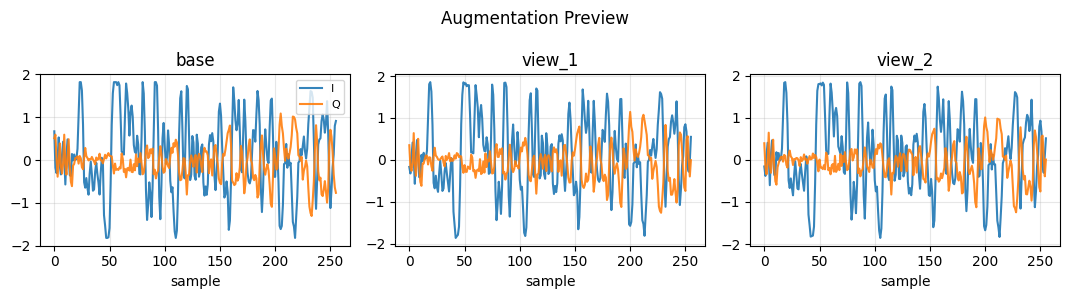

In [4]:
sample = data['iq'][0]
v1 = augment_iq(sample, noise_std=cfg.noise_std, phase_jitter_rad=cfg.phase_jitter_rad, time_shift=cfg.time_shift)
v2 = augment_iq(sample, noise_std=cfg.noise_std, phase_jitter_rad=cfg.phase_jitter_rad, time_shift=cfg.time_shift)
_ = plot_iq_views(sample, [v1, v2], title='Augmentation Preview')


In [5]:
CURRENT_PROFILE = IMPAIRMENT_PROFILE

def run_pipeline(name):
    seed = cfg.seed
    seed_everything(seed, deterministic=True)
    if name == 'real':
        encoder = RealEncoder1D(embed_dim=cfg.embed_dim, pooling=REAL_POOLING)
    else:
        encoder = ComplexEncoder1D(embed_dim=cfg.embed_dim, pooling=COMPLEX_POOLING)

    # pretrain_simclr advances the deterministic augmentation epoch per pass.
    pre_hist = pretrain_simclr(encoder, two_view_ds, cfg, device, seed=seed, deterministic=True, supcon_weight=SUPCON_WEIGHT)
    probe_metrics = run_linear_probe(encoder.to(device), train_ds, test_ds, device)

    ft_model, ft_hist = finetune_classifier(
        encoder=encoder.to(device),
        train_dataset=finetune_train_ds,
        val_dataset=val_ds,
        num_classes=num_classes,
        cfg=cfg,
        device=device,
        supcon_lambda=SUPCON_LAMBDA,
    )

    test_logits, test_labels = collect_logits(ft_model, test_ds, device)
    unknown_logits, _ = collect_logits(ft_model, unknown_ds, device)
    eval_metrics = evaluate_identification(test_logits, test_labels)
    # Verification keeps the raw-embedding protocol. Distance-based open-set
    # scores use clean train embeddings for prototypes/Gaussians and
    # TTA-averaged query embeddings (TTA_VIEWS), which empirically separates
    # better than augmenting both sides.
    raw_test_embeddings, _ = extract_embeddings(ft_model.encoder, test_ds, device)
    train_embeddings, train_embedding_labels = extract_embeddings(ft_model.encoder, train_ds, device)
    train_embeddings = train_embeddings / np.maximum(np.linalg.norm(train_embeddings, axis=1, keepdims=True), 1e-12)
    test_embeddings = extract_embeddings_tta(ft_model.encoder, data['iq'][test_indices], cfg, device, k_views=TTA_VIEWS)
    val_embeddings = extract_embeddings_tta(ft_model.encoder, data['iq'][val_indices], cfg, device, k_views=TTA_VIEWS)
    unknown_embeddings = extract_embeddings_tta(ft_model.encoder, data['iq'][unknown_indices], cfg, device, k_views=TTA_VIEWS)
    calibration_unknown_embeddings = extract_embeddings_tta(ft_model.encoder, data['iq'][unknown_calibration_indices], cfg, device, k_views=TTA_VIEWS)
    verification = evaluate_verification(raw_test_embeddings, test_labels, seed=seed)
    os_metrics = evaluate_open_set(test_logits, unknown_logits)
    oscr_metrics = evaluate_oscr(test_logits, test_labels, unknown_logits)
    known_score_dict = open_set_scores(test_logits)
    unknown_score_dict = open_set_scores(unknown_logits)
    known_score_dict['prototype_cosine'] = prototype_scores(train_embeddings, train_embedding_labels, test_embeddings)
    unknown_score_dict['prototype_cosine'] = prototype_scores(train_embeddings, train_embedding_labels, unknown_embeddings)
    known_score_dict['mahalanobis'] = mahalanobis_scores(train_embeddings, train_embedding_labels, test_embeddings)
    unknown_score_dict['mahalanobis'] = mahalanobis_scores(train_embeddings, train_embedding_labels, unknown_embeddings)
    known_score_dict['knn'] = knn_scores(train_embeddings, test_embeddings, k=KNN_K)
    unknown_score_dict['knn'] = knn_scores(train_embeddings, unknown_embeddings, k=KNN_K)
    calibration_scores = prototype_scores(train_embeddings, train_embedding_labels, calibration_unknown_embeddings)
    test_prototype_scores = known_score_dict['prototype_cosine']
    unknown_prototype_scores = unknown_score_dict['prototype_cosine']
    rejection_threshold = calibrate_rejection_threshold(
        prototype_scores(train_embeddings, train_embedding_labels, val_embeddings),
        calibration_scores,
        target_unknown_far=0.05,
    )
    test_predictions = np.argmax(test_logits, axis=1)
    prototype_oscr = evaluate_prototype_oscr(
        test_prototype_scores, test_labels, test_predictions, unknown_prototype_scores
    )
    val_prototype_scores = prototype_scores(train_embeddings, train_embedding_labels, val_embeddings)
    sweep = rejection_sweep(val_prototype_scores, calibration_scores)
    rejection_metrics = evaluate_rejection(
        test_prototype_scores, unknown_prototype_scores, test_labels,
        test_predictions, rejection_threshold
    )
    score_comparison = compare_open_set_scores(known_score_dict, unknown_score_dict)

    # Outlier-exposure head: calibrates logit-based open-set scores using the
    # designated calibration unknown devices. Test unknowns stay held out.
    oe_model = outlier_exposure_finetune(
        ft_model, train_ds, unknown_calibration_ds, cfg, device,
        oe_weight=OE_WEIGHT, epochs=OE_EPOCHS, encoder_lr_scale=OE_ENCODER_LR_SCALE,
    )
    oe_test_logits, _ = collect_logits(oe_model, test_ds, device)
    oe_unknown_logits, _ = collect_logits(oe_model, unknown_ds, device)
    oe_comparison = compare_open_set_scores(open_set_scores(oe_test_logits), open_set_scores(oe_unknown_logits))

    report = model_report(ft_model, input_shape=(1, cfg.seq_len))
    print(f'{name} model_report:', report)

    row = {
        'encoder': name,
        'profile': CURRENT_PROFILE,
        'pretrain_final_loss': float(pre_hist['loss'][-1]) if pre_hist.get('loss') else float('nan'),
        'probe_acc': float(probe_metrics['probe_acc']),
        'identification_acc': float(eval_metrics['acc']),
        'identification_f1_macro': float(eval_metrics['f1_macro']),
        'verification_auroc': float(verification['auroc']),
        'verification_eer': float(verification['eer']),
        'verification_tpr_at_far_0.01': float(verification['tpr_at_far']['tpr_at_far_0.01']),
        'verification_tpr_at_far_0.05': float(verification['tpr_at_far']['tpr_at_far_0.05']),
        'open_set_auroc': float(score_comparison['prototype_cosine']['auroc']),
        'open_set_oscr_auc': float(prototype_oscr['oscr_auc']),
        **{f'open_set_{name}_auroc': float(metrics['auroc']) for name, metrics in score_comparison.items()},
        **{f'oe_open_set_{name}_auroc': float(metrics['auroc']) for name, metrics in oe_comparison.items()},
        'prototype_threshold': float(rejection_threshold),
        'prototype_known_coverage': float(rejection_metrics['known_coverage']),
        'prototype_unknown_far': float(rejection_metrics['unknown_false_accept_rate']),
        'prototype_accepted_known_accuracy': float(rejection_metrics['accepted_known_accuracy']),
        'comparison_mode': f'complex_pooling={COMPLEX_POOLING}; real-scalar capacity reported',
        'real_scalar_parameters': int(report['real_scalar_parameters']),
    }
    # Per-unknown-device open-set AUROC plus impairment-space separation context.
    unknown_device_ids = data['device_id'][unknown_indices]
    for dev_id in np.unique(unknown_device_ids):
        mask = unknown_device_ids == dev_id
        y = np.r_[np.ones(len(test_prototype_scores)), np.zeros(int(mask.sum()))]
        s = np.r_[test_prototype_scores, unknown_prototype_scores[mask]]
        row[f'unknown_dev_{int(dev_id)}_prototype_auroc'] = float(roc_auc_score(y, s))
    if 'dist_to_nearest_known' in data:
        row['unknown_min_dist_to_known'] = float(np.min(data['dist_to_nearest_known'][unknown_indices]))
    details = {
        'test_logits': test_logits,
        'test_labels': test_labels,
        'unknown_logits': unknown_logits,
        'verification': verification,
        'open_set': os_metrics,
        'oscr': oscr_metrics,
        'prototype_oscr': prototype_oscr,
        'open_set_scores': score_comparison,
        'oe_open_set_scores': oe_comparison,
        'rejection': rejection_metrics,
        'rejection_sweep': sweep,
        'prototype_scores': {
            'validation_known': prototype_scores(train_embeddings, train_embedding_labels, val_embeddings),
            'calibration_unknown': calibration_scores,
            'test_known': test_prototype_scores,
            'test_unknown': unknown_prototype_scores,
        },
        'report': report,
    }
    return row, pre_hist, ft_hist, details

pipeline_outputs = {}
for encoder_name in EVALUATE_ENCODERS:
    pipeline_outputs[encoder_name] = run_pipeline(encoder_name)
real_row, real_pre_hist, real_ft_hist, real_details = pipeline_outputs.get('real', (None, None, None, None))
complex_row, complex_pre_hist, complex_ft_hist, complex_details = pipeline_outputs.get('complex', (None, None, None, None))
scorecard = [output[0] for output in pipeline_outputs.values()]
scorecard


/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/training.py:46: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  sim = torch.matmul(z, z.T) / temperature
/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/training.py:72: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgo

real model_report: {'parameters': 73765, 'trainable_parameters': 73765, 'real_scalar_parameters': 73765, 'trainable_real_scalar_parameters': 73765, 'real_conv_macs': 1368064, 'complex_conv_macs': 0, 'conv_macs': 1368064, 'linear_macs': 41600, 'macs': 1409664, 'output_shape': (1, 5)}


/home/hinson/anaconda3/envs/blog-code-examples/lib/python3.12/site-packages/torch/functional.py:373: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return _VF.einsum(equation, operands)  # type: ignore[attr-defined]
/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/training.py:72: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::

complex model_report: {'parameters': 114504, 'trainable_parameters': 114504, 'real_scalar_parameters': 145928, 'trainable_real_scalar_parameters': 145928, 'real_conv_macs': 0, 'complex_conv_macs': 5357568, 'conv_macs': 5357568, 'linear_macs': 82560, 'macs': 5440128, 'output_shape': (1, 5)}


/home/hinson/anaconda3/envs/blog-code-examples/lib/python3.12/site-packages/torch/functional.py:373: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return _VF.einsum(equation, operands)  # type: ignore[attr-defined]


[{'encoder': 'real',
  'profile': 'controlled',
  'pretrain_final_loss': 6.483564257621765,
  'probe_acc': 0.9132947976878613,
  'identification_acc': 0.928709055876686,
  'identification_f1_macro': 0.930827653359299,
  'verification_auroc': 0.9839802016882049,
  'verification_eer': 0.0602,
  'verification_tpr_at_far_0.01': 0.5792559946216479,
  'verification_tpr_at_far_0.05': 0.9070740270411594,
  'open_set_auroc': 0.7582064868336544,
  'open_set_oscr_auc': 0.7214354527938343,
  'open_set_max_softmax_auroc': 0.4717870905587669,
  'open_set_logit_margin_auroc': 0.4816618497109826,
  'open_set_negative_entropy_auroc': 0.466878612716763,
  'open_set_energy_auroc': 0.39825626204238923,
  'open_set_prototype_cosine_auroc': 0.7582064868336544,
  'open_set_mahalanobis_auroc': 0.7820359666024406,
  'open_set_knn_auroc': 0.713140655105973,
  'oe_open_set_max_softmax_auroc': 0.4490799614643545,
  'oe_open_set_logit_margin_auroc': 0.44904463712267184,
  'oe_open_set_negative_entropy_auroc': 0.45

In [6]:
# Control profiles: run the same pipeline end-to-end on the negative
# control (oracle) and the device-only upper bound (device_full), then
# append their rows to the scorecard with their own profile label.
control_outputs = {}
if RUN_CONTROL_PROFILES:
    primary_cfg, primary_data = cfg, data
    primary_metadata_unavailable = metadata_unavailable
    for profile in RUN_CONTROL_PROFILES:
        if profile == IMPAIRMENT_PROFILE:
            continue
        print(f'=== control profile: {profile} ===')
        cfg = load_config(mode=MODE, impairment_profile=profile, impairment_ablation=IMPAIRMENT_ABLATION)
        for field, value in CONFIG_OVERRIDES.items():
            if value is not None:
                setattr(cfg, field, value)
        cfg.n_devices = KNOWN_DEVICE_COUNT + UNKNOWN_DEVICE_COUNT
        cfg.known_device_count = KNOWN_DEVICE_COUNT
        cfg.unknown_min_separation = MIN_UNKNOWN_SEPARATION
        cfg.validate_impairments()
        data = load_or_generate_npz(cfg)
        seed_everything(cfg.seed, deterministic=True)
        metadata_unavailable = set(np.asarray(data.get('metadata_unavailable', []), dtype=str).tolist())
        if 'dist_to_nearest_known' in data:
            per_dev_dist = [float(np.mean(data['dist_to_nearest_known'][data['device_id'] == d])) for d in np.unique(data['device_id'])]
            print('dist_to_nearest_known per device:', [round(v, 2) for v in per_dev_dist])
        CURRENT_PROFILE = profile
        prepare_experiment(data, metadata_unavailable)
        for encoder_name in EVALUATE_ENCODERS:
            control_outputs[(profile, encoder_name)] = run_pipeline(encoder_name)
    scorecard.extend(output[0] for output in control_outputs.values())
    # Restore the primary experiment context for downstream cells.
    cfg, data = primary_cfg, primary_data
    metadata_unavailable = primary_metadata_unavailable
    CURRENT_PROFILE = IMPAIRMENT_PROFILE
    prepare_experiment(data, metadata_unavailable)
scorecard


/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/training.py:46: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  sim = torch.matmul(z, z.T) / temperature
/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/training.py:72: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgo

=== control profile: oracle ===
dist_to_nearest_known per device: [2.29, 2.31, 2.29, 2.36, 2.31, 2.69, 2.72, 3.35, 2.23, 2.14]
split_strategy: session-held-out known_devices: [0, 1, 2, 3, 4] unknown_calibration_devices: [5, 6] unknown_test_devices: [7, 8, 9]
grouped split semantics: requested fractions apply to groups; actual sample fractions and class coverage: {'train': {'n_samples': 1027, 'sample_fraction': 0.5135, 'class_count': 5, 'class_coverage': 1.0}, 'val': {'n_samples': 500, 'sample_fraction': 0.25, 'class_count': 5, 'class_coverage': 1.0}, 'test': {'n_samples': 473, 'sample_fraction': 0.2365, 'class_count': 5, 'class_coverage': 1.0}}


/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/training.py:72: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  sim = torch.matmul(features, features.T) / temperature
/home/hinson/anaconda3/envs/blog-code-examples/lib/python3.12/site-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterm

real model_report: {'parameters': 73765, 'trainable_parameters': 73765, 'real_scalar_parameters': 73765, 'trainable_real_scalar_parameters': 73765, 'real_conv_macs': 1368064, 'complex_conv_macs': 0, 'conv_macs': 1368064, 'linear_macs': 41600, 'macs': 1409664, 'output_shape': (1, 5)}


/home/hinson/anaconda3/envs/blog-code-examples/lib/python3.12/site-packages/torch/functional.py:373: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return _VF.einsum(equation, operands)  # type: ignore[attr-defined]
/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/training.py:72: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::

...

real model_report: {'parameters': 73765, 'trainable_parameters': 73765, 'real_scalar_parameters': 73765, 'trainable_real_scalar_parameters': 73765, 'real_conv_macs': 1368064, 'complex_conv_macs': 0, 'conv_macs': 1368064, 'linear_macs': 41600, 'macs': 1409664, 'output_shape': (1, 5)}


/home/hinson/anaconda3/envs/blog-code-examples/lib/python3.12/site-packages/torch/functional.py:373: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return _VF.einsum(equation, operands)  # type: ignore[attr-defined]
/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/training.py:72: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::

complex model_report: {'parameters': 114504, 'trainable_parameters': 114504, 'real_scalar_parameters': 145928, 'trainable_real_scalar_parameters': 145928, 'real_conv_macs': 0, 'complex_conv_macs': 5357568, 'conv_macs': 5357568, 'linear_macs': 82560, 'macs': 5440128, 'output_shape': (1, 5)}
split_strategy: session-held-out known_devices: [0, 1, 2, 3, 4] unknown_calibration_devices: [5, 6] unknown_test_devices: [7, 8, 9]
grouped split semantics: requested fractions apply to groups; actual sample fractions and class coverage: {'train': {'n_samples': 969, 'sample_fraction': 0.4845, 'class_count': 5, 'class_coverage': 1.0}, 'val': {'n_samples': 512, 'sample_fraction': 0.256, 'class_count': 5, 'class_coverage': 1.0}, 'test': {'n_samples': 519, 'sample_fraction': 0.2595, 'class_count': 5, 'class_coverage': 1.0}}


/home/hinson/anaconda3/envs/blog-code-examples/lib/python3.12/site-packages/torch/functional.py:373: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return _VF.einsum(equation, operands)  # type: ignore[attr-defined]


[{'encoder': 'real',
  'profile': 'controlled',
  'pretrain_final_loss': 6.483564257621765,
  'probe_acc': 0.9132947976878613,
  'identification_acc': 0.928709055876686,
  'identification_f1_macro': 0.930827653359299,
  'verification_auroc': 0.9839802016882049,
  'verification_eer': 0.0602,
  'verification_tpr_at_far_0.01': 0.5792559946216479,
  'verification_tpr_at_far_0.05': 0.9070740270411594,
  'open_set_auroc': 0.7582064868336544,
  'open_set_oscr_auc': 0.7214354527938343,
  'open_set_max_softmax_auroc': 0.4717870905587669,
  'open_set_logit_margin_auroc': 0.4816618497109826,
  'open_set_negative_entropy_auroc': 0.466878612716763,
  'open_set_energy_auroc': 0.39825626204238923,
  'open_set_prototype_cosine_auroc': 0.7582064868336544,
  'open_set_mahalanobis_auroc': 0.7820359666024406,
  'open_set_knn_auroc': 0.713140655105973,
  'oe_open_set_max_softmax_auroc': 0.4490799614643545,
  'oe_open_set_logit_margin_auroc': 0.44904463712267184,
  'oe_open_set_negative_entropy_auroc': 0.45

## Post-training metrics

The plots below compare representation learning, closed-set identification, same-device verification, and prototype-cosine rejection of unseen devices. Lower SimCLR loss and verification EER are better; higher accuracy, macro-F1, AUROC, TPR-at-FAR, and OSCR AUC are better.

- **SimCLR loss:** whether two augmented views of the same IQ sample are pulled together while other samples are separated.
- **Validation accuracy:** known-device accuracy used during fine-tuning checkpoint selection.
- **Identification accuracy:** fraction of known-device test samples assigned the correct device.
- **Macro-F1:** average device F1, giving each device equal weight despite imbalance.
- **Verification AUROC:** ability to distinguish same-device from different-device pairs over all thresholds.
- **EER:** approximate point where false-accept and false-reject rates are equal; lower is better.
- **TPR at FAR:** genuine-device acceptance rate at a specified false-accept rate; higher is better.
- **Open-set AUROC:** ability to distinguish enrolled devices from unseen devices using classifier confidence.
- **OSCR AUC:** tradeoff between correctly classifying known devices and rejecting unknown devices.
- **Confidence distributions:** unknown devices should generally have lower max-softmax confidence than known devices.

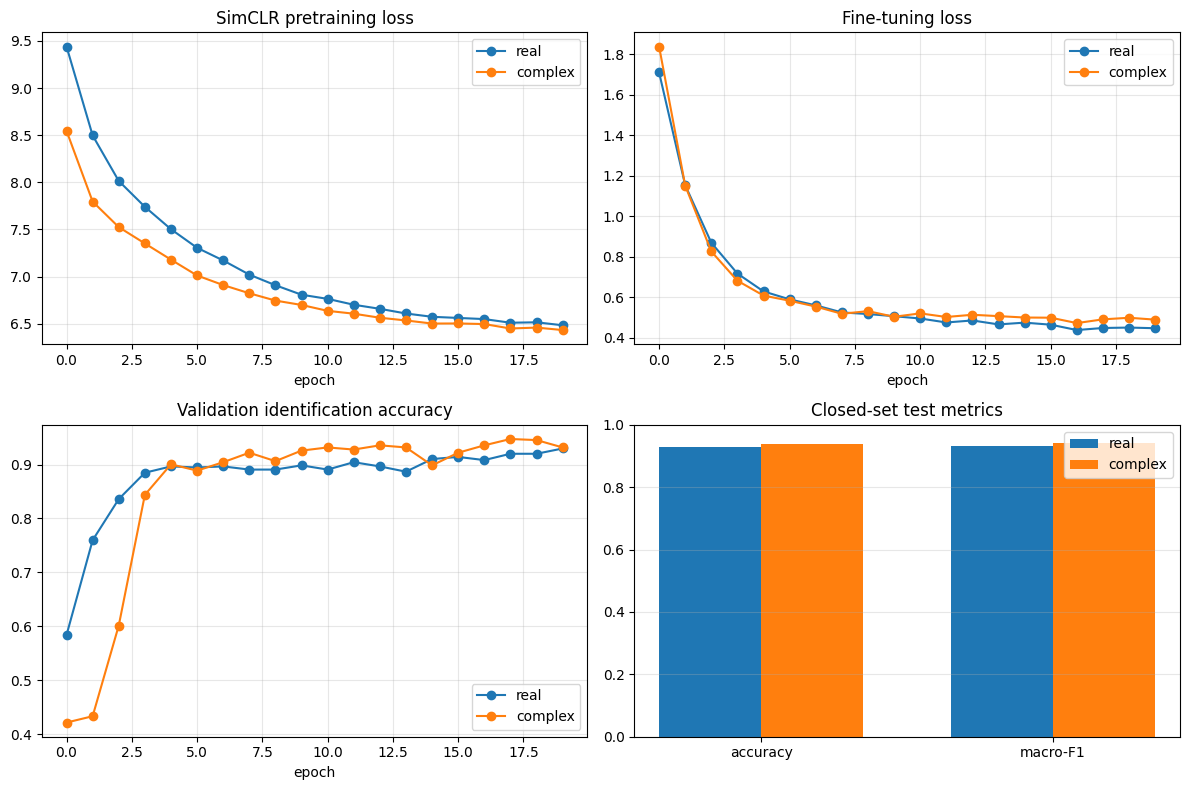

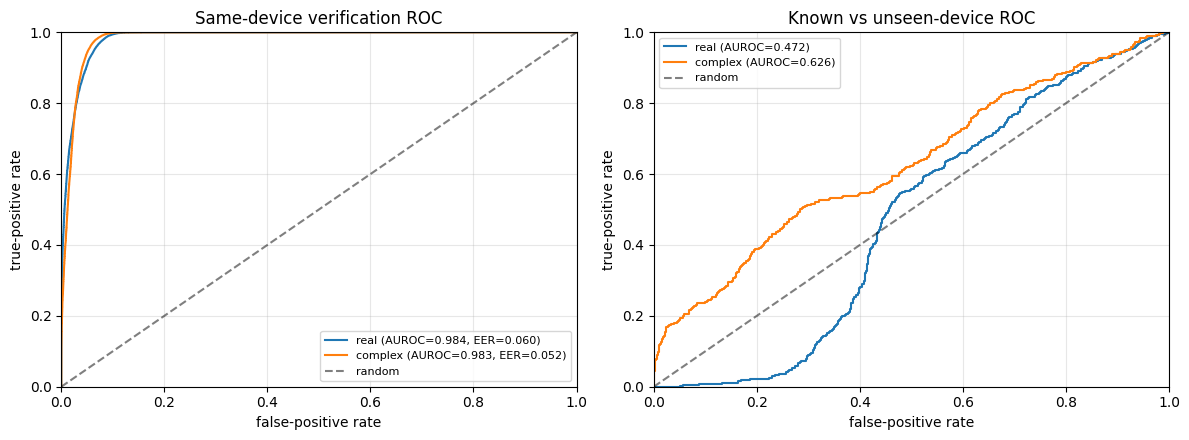

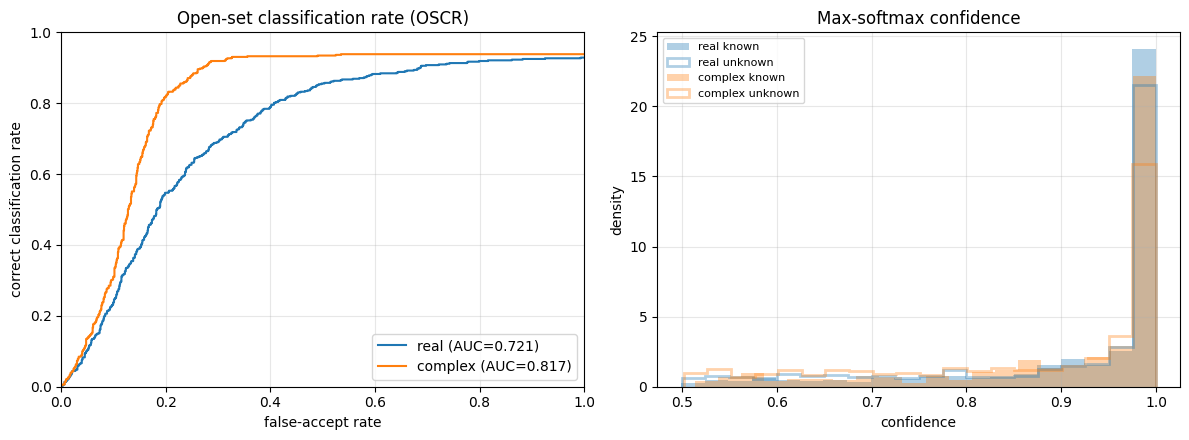

In [7]:
results = {name: (output[1], output[2], output[3]) for name, output in pipeline_outputs.items()}
colors = {'real': 'tab:blue', 'complex': 'tab:orange'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for name, (pre_hist, ft_hist, _) in results.items():
    for ax, history, key, label in ((axes[0, 0], pre_hist, 'loss', 'pretraining loss'), (axes[0, 1], ft_hist, 'loss', 'fine-tuning loss'), (axes[1, 0], ft_hist, 'val_acc', 'validation accuracy')):
        values = history.get(key, [])
        if values:
            ax.plot(values, marker='o', label=name, color=colors[name])
        else:
            print(f'{name}: no {label} history to plot')
axes[0, 0].set_title('SimCLR pretraining loss')
axes[0, 1].set_title('Fine-tuning loss')
axes[1, 0].set_title('Validation identification accuracy')
for ax in axes.flat[:3]:
    ax.set_xlabel('epoch')
    ax.grid(alpha=0.3)
    if ax.lines:
        ax.legend()
metric_names = ['identification_acc', 'identification_f1_macro']
x = np.arange(len(metric_names))
width = 0.35
for i, name in enumerate(results):
    values = [scorecard[i][metric] for metric in metric_names]
    axes[1, 1].bar(x + (i - 0.5) * width, values, width, label=name, color=colors[name])
axes[1, 1].set_xticks(x, ['accuracy', 'macro-F1'])
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title('Closed-set test metrics')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, (_, _, details) in results.items():
    verification = details['verification']
    open_set = details['open_set']
    if len(verification.get('fpr', [])) and len(verification.get('tpr', [])):
        axes[0].plot(verification['fpr'], verification['tpr'], label=f"{name} (AUROC={verification['auroc']:.3f}, EER={verification['eer']:.3f})", color=colors[name])
    else:
        print(f'{name}: no verification ROC data to plot')
    if len(open_set.get('fpr', [])) and len(open_set.get('tpr', [])):
        axes[1].plot(open_set['fpr'], open_set['tpr'], label=f"{name} (AUROC={open_set['auroc']:.3f})", color=colors[name])
    else:
        print(f'{name}: no open-set ROC data to plot')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='random')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='random')
axes[0].set_title('Same-device verification ROC')
axes[1].set_title('Known vs unseen-device ROC')
for ax in axes:
    ax.set_xlabel('false-positive rate')
    ax.set_ylabel('true-positive rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    if ax.lines:
        ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, (_, _, details) in results.items():
    oscr = details['prototype_oscr']
    if len(oscr.get('far', [])) and len(oscr.get('ccr', [])):
        axes[0].plot(oscr['far'], oscr['ccr'], label=f"{name} (AUC={oscr['oscr_auc']:.3f})", color=colors[name])
    else:
        print(f'{name}: no OSCR data to plot')
    if details['test_logits'].size and details['unknown_logits'].size:
        id_conf = max_softmax_scores(details['test_logits'])
        ood_conf = max_softmax_scores(details['unknown_logits'])
        axes[1].hist(id_conf, bins=20, alpha=0.35, density=True, label=f'{name} known', color=colors[name])
        axes[1].hist(ood_conf, bins=20, alpha=0.35, density=True, histtype='step', linewidth=2, label=f'{name} unknown', color=colors[name])
    else:
        print(f'{name}: no logits for confidence distributions')
axes[0].set_title('Open-set classification rate (OSCR)')
axes[0].set_xlabel('false-accept rate')
axes[0].set_ylabel('correct classification rate')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
if axes[0].lines:
    axes[0].legend()
axes[1].set_title('Max-softmax confidence')
axes[1].set_xlabel('confidence')
axes[1].set_ylabel('density')
axes[1].grid(alpha=0.3)
if axes[1].patches or axes[1].lines:
    axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

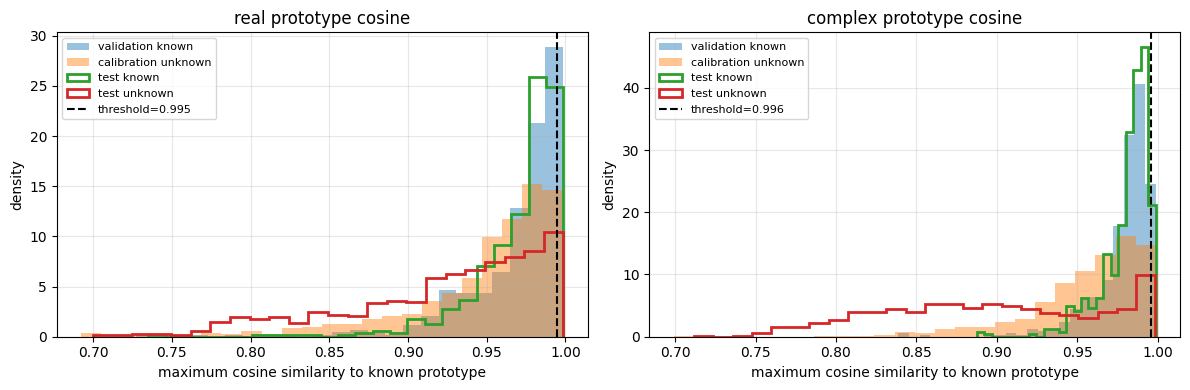

In [8]:
fig, axes = plt.subplots(1, len(results), figsize=(12, 4), squeeze=False)
for ax, (name, (_, _, details)) in zip(axes[0], results.items()):
    scores = details['prototype_scores']
    ax.hist(scores['validation_known'], bins=24, alpha=0.45, density=True, label='validation known')
    ax.hist(scores['calibration_unknown'], bins=24, alpha=0.45, density=True, label='calibration unknown')
    ax.hist(scores['test_known'], bins=24, histtype='step', linewidth=2, density=True, label='test known')
    ax.hist(scores['test_unknown'], bins=24, histtype='step', linewidth=2, density=True, label='test unknown')
    threshold = details['rejection']['threshold']
    ax.axvline(threshold, color='black', linestyle='--', label=f'threshold={threshold:.3f}')
    ax.set_title(f'{name} prototype cosine')
    ax.set_xlabel('maximum cosine similarity to known prototype')
    ax.set_ylabel('density')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

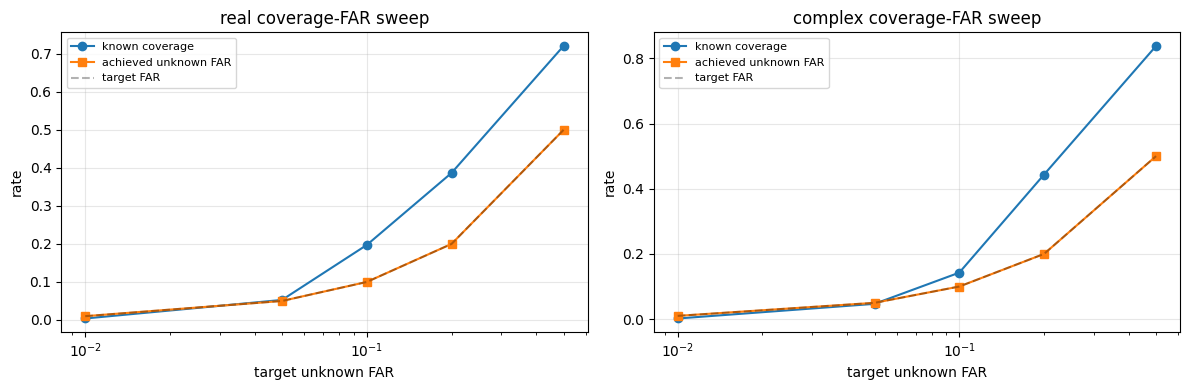

real rejection sweep:
  FAR<=0.01: threshold=0.9973 coverage=0.004 achieved_far=0.010
  FAR<=0.05: threshold=0.9946 coverage=0.053 achieved_far=0.050
  FAR<=0.1: threshold=0.9908 coverage=0.197 achieved_far=0.100
  FAR<=0.2: threshold=0.9845 coverage=0.387 achieved_far=0.200
  FAR<=0.5: threshold=0.9631 coverage=0.721 achieved_far=0.500
complex rejection sweep:
  FAR<=0.01: threshold=0.9978 coverage=0.002 achieved_far=0.010
  FAR<=0.05: threshold=0.9958 coverage=0.047 achieved_far=0.050
  FAR<=0.1: threshold=0.9929 coverage=0.143 achieved_far=0.100
  FAR<=0.2: threshold=0.9854 coverage=0.443 achieved_far=0.200
  FAR<=0.5: threshold=0.9652 coverage=0.838 achieved_far=0.500


In [9]:
fig, axes = plt.subplots(1, len(results), figsize=(12, 4), squeeze=False)
for ax, (name, (_, _, details)) in zip(axes[0], results.items()):
    sweep = details['rejection_sweep']
    fars = sorted(sweep.keys())
    coverages = [sweep[f]['known_coverage'] for f in fars]
    achieved = [sweep[f]['unknown_far'] for f in fars]
    ax.plot(fars, coverages, marker='o', label='known coverage')
    ax.plot(fars, achieved, marker='s', label='achieved unknown FAR')
    ax.plot(fars, fars, 'k--', alpha=0.3, label='target FAR')
    ax.set_xlabel('target unknown FAR')
    ax.set_ylabel('rate')
    ax.set_title(f'{name} coverage-FAR sweep')
    ax.set_xscale('log')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
for name, (_, _, details) in results.items():
    sweep = details['rejection_sweep']
    print(f'{name} rejection sweep:')
    for far in sorted(sweep):
        op = sweep[far]
        print(f'  FAR<={far:g}: threshold={op["threshold"]:.4f} coverage={op["known_coverage"]:.3f} achieved_far={op["unknown_far"]:.3f}')

In [10]:
summary_columns = [
    'encoder', 'profile', 'identification_acc', 'identification_f1_macro',
    'verification_auroc', 'verification_eer',
    'verification_tpr_at_far_0.01', 'verification_tpr_at_far_0.05',
    'open_set_auroc', 'open_set_mahalanobis_auroc', 'open_set_knn_auroc', 'oe_open_set_max_softmax_auroc',
    'open_set_oscr_auc', 'unknown_min_dist_to_known',
]
metric_summary = [{key: row.get(key) for key in summary_columns} for row in scorecard]
metric_summary


[{'encoder': 'real',
  'profile': 'controlled',
  'identification_acc': 0.928709055876686,
  'identification_f1_macro': 0.930827653359299,
  'verification_auroc': 0.9839802016882049,
  'verification_eer': 0.0602,
  'verification_tpr_at_far_0.01': 0.5792559946216479,
  'verification_tpr_at_far_0.05': 0.9070740270411594,
  'open_set_auroc': 0.7582064868336544,
  'open_set_mahalanobis_auroc': 0.7820359666024406,
  'open_set_knn_auroc': 0.713140655105973,
  'oe_open_set_max_softmax_auroc': 0.4490799614643545,
  'open_set_oscr_auc': 0.7214354527938343,
  'unknown_min_dist_to_known': 2.1417229175567627},
 {'encoder': 'complex',
  'profile': 'controlled',
  'identification_acc': 0.9383429672447013,
  'identification_f1_macro': 0.9404907447266465,
  'verification_auroc': 0.9830973631134683,
  'verification_eer': 0.05182,
  'verification_tpr_at_far_0.01': 0.44606708000298795,
  'verification_tpr_at_far_0.05': 0.9419586165683126,
  'open_set_auroc': 0.8671933204881181,
  'open_set_mahalanobis_au

In [11]:
scorecard_path = f"{cfg.output_dir}/scorecard.csv"
save_scorecard_csv(scorecard_path, scorecard)
print('scorecard_csv:', scorecard_path)
scorecard

scorecard_csv: /home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_full/scorecard.csv


[{'encoder': 'real',
  'profile': 'controlled',
  'pretrain_final_loss': 6.483564257621765,
  'probe_acc': 0.9132947976878613,
  'identification_acc': 0.928709055876686,
  'identification_f1_macro': 0.930827653359299,
  'verification_auroc': 0.9839802016882049,
  'verification_eer': 0.0602,
  'verification_tpr_at_far_0.01': 0.5792559946216479,
  'verification_tpr_at_far_0.05': 0.9070740270411594,
  'open_set_auroc': 0.7582064868336544,
  'open_set_oscr_auc': 0.7214354527938343,
  'open_set_max_softmax_auroc': 0.4717870905587669,
  'open_set_logit_margin_auroc': 0.4816618497109826,
  'open_set_negative_entropy_auroc': 0.466878612716763,
  'open_set_energy_auroc': 0.39825626204238923,
  'open_set_prototype_cosine_auroc': 0.7582064868336544,
  'open_set_mahalanobis_auroc': 0.7820359666024406,
  'open_set_knn_auroc': 0.713140655105973,
  'oe_open_set_max_softmax_auroc': 0.4490799614643545,
  'oe_open_set_logit_margin_auroc': 0.44904463712267184,
  'oe_open_set_negative_entropy_auroc': 0.45

## Scorecard metric glossary

Every row of the scorecard CSV (and the list above) is one encoder configuration. All metrics are computed on the held-out test split unless otherwise noted. Higher is better for every metric except pretrain loss, verification EER, and unknown FAR.

### Representation learning

- **pretrain_final_loss**: NT-Xent contrastive loss on the *pretraining* train split after the last SimCLR (and optional supervised-contrastive) epoch. Tracks whether the encoder learned to pull two augmented views of the same IQ sample together while pushing other samples apart. Lower means a better self-supervised representation. The validation split is *not* used for self-supervised training, so this number is a training-set diagnostic rather than a generalization score.

### Closed-set identification (known devices only)

- **probe_acc**: linear-probe accuracy on the held-out test split. A logistic-regression head is fit on frozen encoder embeddings from the *train* split and evaluated on the test split. This is the cleanest measure of how linearly separable the learned representation is.
- **identification_acc**: end-to-end classification accuracy of the fine-tuned classifier on the held-out test split. Includes the effect of the classification head, so it can differ from the linear probe when the head helps (or hurts).
- **identification_f1_macro**: macro-averaged F1 of the fine-tuned classifier, weighting every known device equally. Use this in addition to accuracy when the number of samples per device is uneven.

### Pairwise verification (known vs known)

All verification metrics are computed on cosine-similarity scores over held-out test embeddings. A *genuine* pair is two samples from the same device; an *impostor* pair is two samples from different devices.

- **verification_auroc**: probability that a randomly chosen genuine pair scores higher than a randomly chosen impostor pair under cosine similarity. 1.0 is perfect, 0.5 is random.
- **verification_eer**: equal error rate, the point where the false-accept rate (impostors above the threshold) and the false-reject rate (genuines below the threshold) cross. Lower is better; the EER is a single-threshold summary of the ROC curve.
- **verification_tpr_at_far_0.01** and **verification_tpr_at_far_0.05**: true-positive rate (fraction of genuine pairs accepted) when the threshold is set to a fixed false-accept rate of 1% and 5% respectively. These are deployment-oriented operating points: "at 1% impostor acceptance, what fraction of genuine devices do we still accept?"

### Open-set recognition (known vs unknown)

All open-set metrics use the *unseen* unknown-device set, which is held out from training, validation, and threshold calibration. Two unknown devices are reserved for threshold calibration; the remaining unknown devices are used for these metrics so the calibration target is independent of the evaluation.

- **open_set_auroc** (alias of **open_set_prototype_cosine_auroc**): probability that a known-device sample is scored higher than an unknown-device sample by the prototype-cosine score (max cosine similarity to any known-device prototype). 1.0 means perfectly separable.
- **open_set_oscr_auc**: area under the Open Set Classification Rate curve, which plots the fraction of known samples classified correctly against the fraction of unknown samples rejected as the threshold sweeps. Captures the *joint* tradeoff between closed-set accuracy and open-set rejection; higher is better.
- **open_set_max_softmax_auroc**, **open_set_logit_margin_auroc**, **open_set_negative_entropy_auroc**, **open_set_energy_auroc**: same AUROC computed from four alternative confidence scores (max softmax probability, top-1 minus top-2 logit, negative predictive entropy, and negative free energy at temperature T). They are kept as comparison columns; prototype cosine is the primary score because it operates directly on embeddings and does not depend on classifier calibration.

### Prototype rejection operating point

The threshold is chosen on the two calibration unknown devices, then frozen and evaluated on the remaining unknown devices.

- **prototype_threshold**: cosine-similarity threshold chosen by `calibrate_rejection_threshold`. Samples with prototype cosine *at or above* this threshold are accepted as a known device; below, they are rejected as unknown.
- **prototype_known_coverage**: fraction of known-device test samples whose prototype cosine is at or above the threshold (i.e., accepted as known). Higher means fewer known devices are mistakenly rejected.
- **prototype_unknown_far**: false-accept rate, the fraction of unknown-device test samples whose prototype cosine is at or above the threshold (i.e., mistakenly accepted as known). Lower is better.
- **prototype_accepted_known_accuracy**: classification accuracy of the fine-tuned classifier, restricted to known-device test samples that pass the rejection threshold. This is the operational accuracy a deployment would see, because rejected samples are not assigned a device label.

### Model reporting

- **real_scalar_parameters**: count of real-valued scalar parameters. A complex-valued parameter `a + jb` is reported as two real scalars. This makes the real and complex encoders directly comparable on parameter count and is the basis of the capacity discussion in the README.
- **comparison_mode**: free-form note describing the pooling, training, and calibration settings used for the row, so the CSV remains interpretable when settings change.
### Open-set scoring additions

- **profile**: impairment profile the row was evaluated under. The main experiment rows carry `IMPAIRMENT_PROFILE`; control rows carry the control profile name.
- **open_set_mahalanobis_auroc**: AUROC of the negative minimum Mahalanobis distance to class-conditional Gaussians (shared shrunk covariance) fit on train embeddings. Operates on the same TTA embeddings as prototype cosine but models per-class spread rather than just the mean.
- **open_set_knn_auroc**: AUROC of the mean cosine similarity to the `KNN_K` nearest train embeddings. Sensitive to local cluster structure that a single per-class prototype misses.
- **oe_open_set_max_softmax_auroc**, **oe_open_set_logit_margin_auroc**, **oe_open_set_negative_entropy_auroc**, **oe_open_set_energy_auroc**: logit-based open-set AUROCs computed from the outlier-exposure head instead of the closed-set head. Outlier exposure uses only the two designated calibration unknown devices, so the test unknown devices remain held out.
- **unknown_dev_<id>_prototype_auroc**: prototype-cosine open-set AUROC computed against each unknown test device individually. Reveals whether a single hard-to-separate device drags down the aggregate AUROC.
- **unknown_min_dist_to_known**: minimum impairment-space distance (standard-deviation units) from the unknown test devices to the nearest known device. Direct measure of how hard the open-set problem is for a given seed; with `MIN_UNKNOWN_SEPARATION` this is guaranteed to be at or above the configured floor.

Embedding-based scores (prototype cosine, Mahalanobis) use L2-normalized clean train embeddings for the reference and test-time-augmented query embeddings (`TTA_VIEWS`).
